***** UNIT 2 CODE *****

In [ ]:
# Explicity Mount Google Drive via python library import.
# Connects the Google Drive to the notebook's virtual machine.
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
!pip install serpapi

In [ ]:
path = '/content/drive/My Drive/CIS617_TextAnalytics/TextAnalyticsCode_FordKCAP'
import pandas as pd

In [ ]:
from serpapi import search

params = {

}
res = []
for x in range(20):
  print(x)
  results = search(params)
  if "error" in results:
    print(results["error"])
    break
  next_page_token  = results["serpapi_pagination"]["next_page_token"]
  res.append(results)
  params["next_page_token"] = next_page_token
reviews = []
for x in res:
  reviews.append(pd.DataFrame(x["reviews"]))
reviews = pd.concat(reviews)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [ ]:
# Remove all index columns formed while building database. This avoids index innacuracies.
reviews.reset_index(drop=True, inplace=True)
reviews = reviews.drop(columns=['position'])

In [ ]:
# Create new position column for locating reviews. Set this column as the df index
reviews['review_position'] = range(1, len(reviews) + 1)
reviews.set_index('review_position', inplace=True)

reviews.head(20)

,link,rating,date,iso_date,iso_date_of_last_edit,source,review_id,user,snippet,extracted_snippet,likes,images
review_position,,,,,,,,,,,,
1,https://www.google.com/maps/reviews/data=!4m8!...,5.0,5 months ago,2025-10-29T03:17:23Z,2025-10-29T03:17:23Z,Google,Ci9DQUlRQUNvZENodHljRjlvT214UlZHNXlhbXBUWjI1Rl...,"{'name': 'Sarah Tasciotti', 'link': 'https://w...",Easy drop and hook. Never had a problem with s...,{'original': 'Easy drop and hook. Never had a ...,0,NaN
2,https://www.google.com/maps/reviews/data=!4m8!...,1.0,3 months ago,2025-12-28T14:33:40Z,2025-12-28T14:33:40Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25rMFMxRjBSbWxWY213ek...,"{'name': 'Kaden Ash Richardson', 'link': 'http...",You make living across from you hell. Constant...,{'original': 'You make living across from you ...,0,NaN
3,https://www.google.com/maps/reviews/data=!4m8!...,1.0,Edited 5 months ago,2025-10-02T11:39:10Z,2025-10-10T14:14:55Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2pCaGFGUlBNMnR1UXpsdV...,"{'name': 'T Gold', 'link': 'https://www.google...",Trucker beware... Mostly everyone is helpful e...,{'original': 'Trucker beware... Mostly everyon...,0,NaN
4,https://www.google.com/maps/reviews/data=!4m8!...,1.0,2 months ago,2026-01-30T09:53:12Z,2026-01-30T09:53:12Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2pSQlFqZ3dkRVJJY25Kdm...,"{'name': 'William Bray', 'link': 'https://www....",Lady night check in very rude I been completel...,{'original': 'Lady night check in very rude I ...,0,NaN
5,https://www.google.com/maps/reviews/data=!4m8!...,1.0,2 months ago,2026-01-25T22:36:08Z,2026-01-25T22:39:46Z,Google,Ci9DQUlRQUNvZENodHljRjlvT21Wd2VXUjNYemxZYmtKU1...,"{'name': 'B_e_l_a_l Alwajih', 'link': 'https:/...",All the security at the factory are kind and e...,{'original': 'All the security at the factory ...,0,NaN
6,https://www.google.com/maps/reviews/data=!4m8!...,4.0,2 years ago,2024-01-23T16:45:33Z,2024-01-23T16:45:33Z,Google,ChZDSUhNMG9nS0VJQ0FnSUROeWJuRFZBEAE,"{'name': 'Willie Rice', 'link': 'https://www.g...",Last time I delivered there the line was out t...,{'original': 'Last time I delivered there the ...,0,[https://lh3.googleusercontent.com/geougc-cs/A...
7,https://www.google.com/maps/reviews/data=!4m8!...,1.0,3 years ago,2022-10-13T01:55:22Z,2022-10-13T01:55:35Z,Google,ChZDSUhNMG9nS0VJQ0FnSURlOGRUb1N3EAE,"{'name': 'Andrei Petrov', 'link': 'https://www...","Just pulled into this Ford, gate 6... I have a...","{'original': 'Just pulled into this Ford, gate...",24,[https://lh3.googleusercontent.com/geougc-cs/A...
8,https://www.google.com/maps/reviews/data=!4m8!...,3.0,a month ago,2026-02-22T22:29:04Z,2026-02-22T22:29:04Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2xnNGEyUlJXVk5qU2poMk...,"{'name': 'Jack King', 'link': 'https://www.goo...",People they aren't open 24 hours they close on...,{'original': 'People they aren't open 24 hours...,0,NaN
9,https://www.google.com/maps/reviews/data=!4m8!...,2.0,a year ago,2024-11-14T14:55:05Z,2024-11-14T14:56:20Z,Google,ChZDSUhNMG9nS0VJQ0FnSUQzaHBlTllBEAE,"{'name': 'Cazim Melkic', 'link': 'https://www....",Just got here and the directions from guards f...,{'original': 'Just got here and the directions...,0,[https://lh3.googleusercontent.com/geougc-cs/A...


In [ ]:
reviews.to_csv(path+'/reviews.csv')

In [ ]:
# Creating Bag of Words

from nltk.stem.snowball import stopwords
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

import re

dataset = reviews['snippet'].to_list()

for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

word_counts = {}

for sentence in dataset:
    words = nltk.word_tokenize(sentence)
    for word in words:
        if word not in word_counts:
            word_counts[word] = 1
        else:
            word_counts[word] += 1
stop_words = set(stopwords.words('english'))
for word in list(word_counts.keys()):
    if word in stop_words:
        del word_counts[word]

word_counts_df = pd.DataFrame.from_dict(word_counts, orient='index', columns=['count'])
word_counts_df.sort_values(by=['count'], ascending=False, inplace=True)
top_words = word_counts_df.head(10)
top_words

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,count
place,52
ford,46
trailer,45
drop,39
rude,38
time,36
truck,36
get,34
like,34
plant,28


In [ ]:
words_in_reviews = []
for sentence in dataset:
  words = nltk.word_tokenize(sentence)
  sentence_vector = {}
  for top_word in top_words.index:
    if top_word in words:
      sentence_vector[top_word] = True
    else:
      sentence_vector[top_word] = False
  words_in_reviews.append(sentence_vector)
words_in_reviews_df = pd.DataFrame(words_in_reviews)
words_in_reviews_df

,place,ford,trailer,drop,rude,time,truck,get,like,plant
0,False,False,False,True,False,False,False,False,False,False
1,False,True,False,False,False,True,False,False,False,False
2,False,False,True,False,False,True,False,False,True,False
3,False,True,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
193,False,False,False,False,False,False,False,False,False,True
194,False,False,False,False,True,False,False,False,False,False
195,False,False,False,False,True,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False


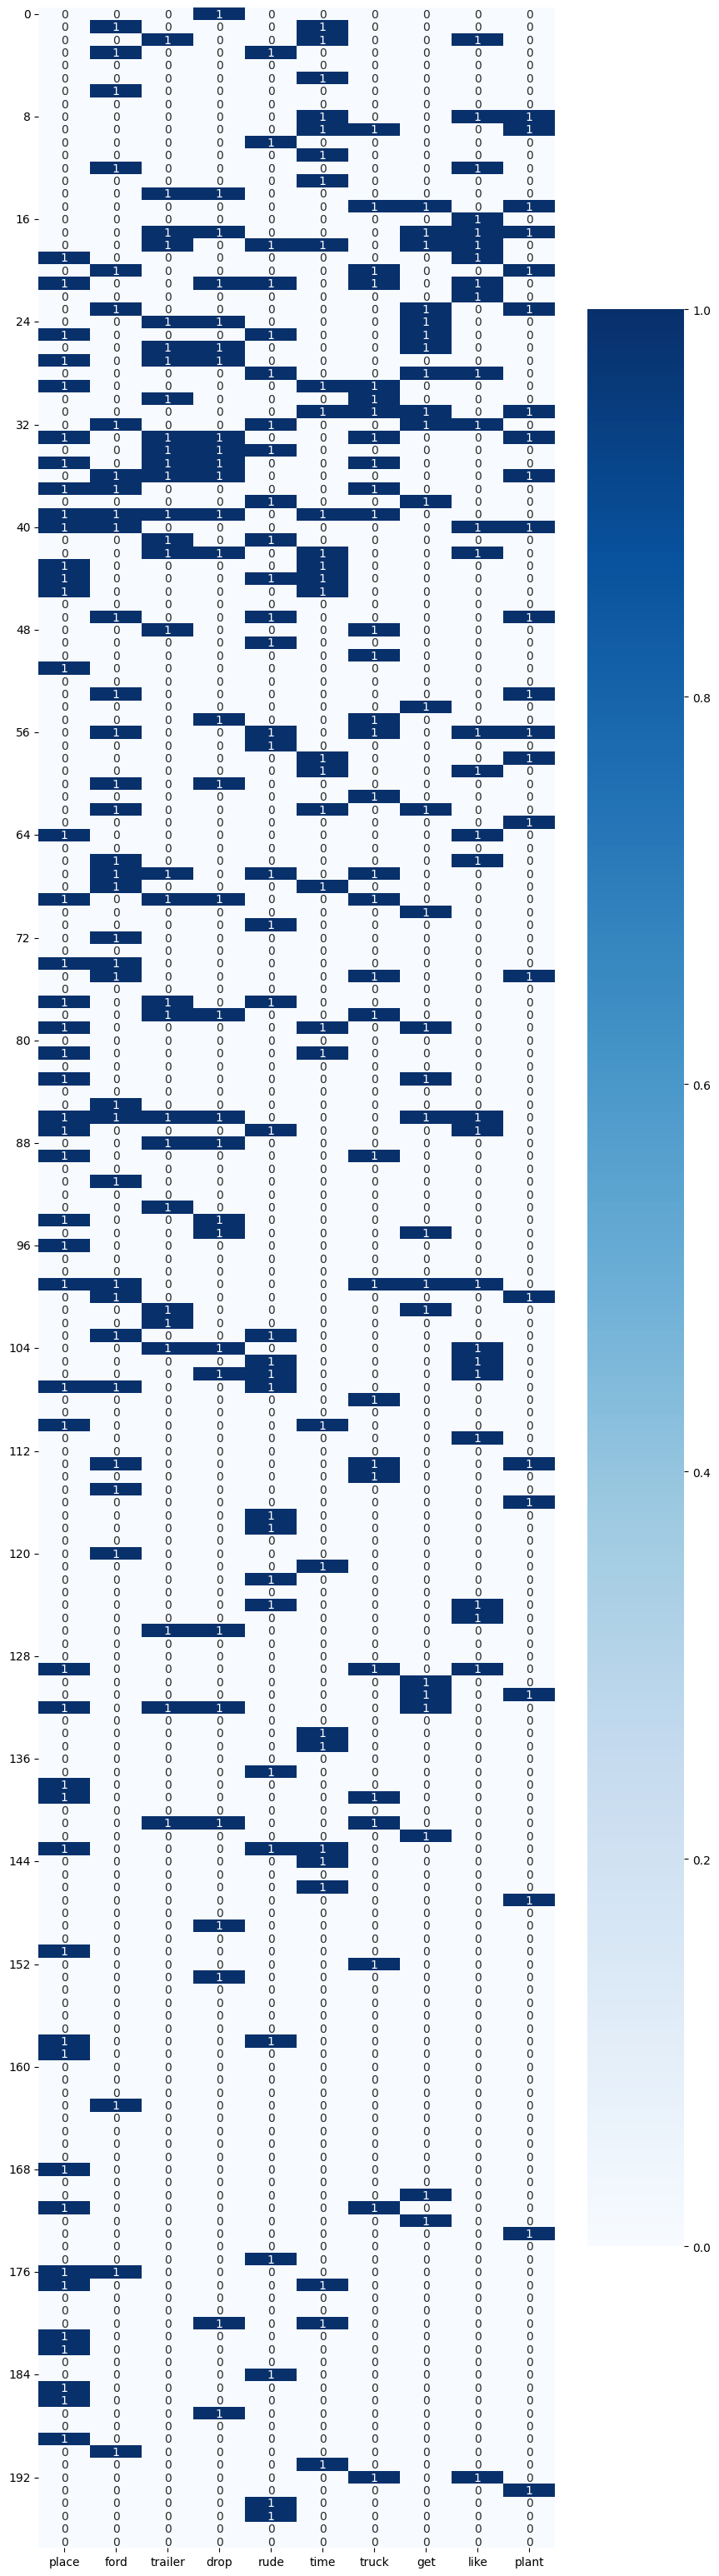

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.heatmap(words_in_reviews_df,  annot=True, cmap='Blues')
fig = ax.get_figure()
fig.set_size_inches(10, 0.2*len(dataset))
plt.show()

In [ ]:
#df_reviews = pd.read_csv('/content/drive/My Drive/CIS617_TextAnalytics/TextAnalyticsCode_FordKCAP/reviews.csv')
#df_reviews.head()

In [ ]:
word_counts_df.head(20)

,count
place,52
ford,46
trailer,45
drop,39
rude,38
time,36
truck,36
get,34
like,34
plant,28
